In [247]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
from itertools import groupby
from operator import itemgetter
import matplotlib.colors as colors
import seaborn as sns

In [248]:
files = glob.glob("../hdf5_files/*")

In [249]:
files

['../hdf5_files/event_211274458.h5',
 '../hdf5_files/event_256893462.h5',
 '../hdf5_files/event_216741224.h5',
 '../hdf5_files/event_236442324.h5',
 '../hdf5_files/event_242764060.h5',
 '../hdf5_files/event_212636270.h5',
 '../hdf5_files/event_219288990.h5',
 '../hdf5_files/event_239076863.h5',
 '../hdf5_files/event_222684112.h5',
 '../hdf5_files/event_221627323.h5',
 '../hdf5_files/event_98790022.h5',
 '../hdf5_files/event_109687805.h5',
 '../hdf5_files/event_126350302.h5',
 '../hdf5_files/event_222848068.h5',
 '../hdf5_files/event_258517814.h5',
 '../hdf5_files/event_239712228.h5',
 '../hdf5_files/event_211047255.h5',
 '../hdf5_files/event_95818679.h5',
 '../hdf5_files/event_259787063.h5',
 '../hdf5_files/event_131043138.h5',
 '../hdf5_files/event_259870951.h5',
 '../hdf5_files/event_93970574.h5']

In [250]:
cov_fn = glob.glob("results/Covs/*")

In [251]:
cov_fn

['results/Covs/event_222684112_100',
 'results/Covs/event_239076863_100',
 'results/Covs/event_259787063_100',
 'results/Covs/event_131043138_100',
 'results/Covs/event_216741224_100',
 'results/Covs/event_98790022_100',
 'results/Covs/event_258517814_100',
 'results/Covs/event_221627323_100',
 'results/Covs/event_256893462_100',
 'results/Covs/event_259870951_100',
 'results/Covs/event_126350302_100',
 'results/Covs/event_219288990_100',
 'results/Covs/event_236442324_100',
 'results/Covs/event_93970574_100',
 'results/Covs/event_95818679_100',
 'results/Covs/event_239712228_100',
 'results/Covs/event_212636270_100',
 'results/Covs/event_109687805_100',
 'results/Covs/event_211047255_100',
 'results/Covs/event_211274458_100',
 'results/Covs/event_222848068_100']

In [252]:
import re

In [253]:
# Helper function to extract numerical ID
def get_id(filepath):
    match = re.search(r'event_(\d+)', filepath)
    return match.group(1) if match else None

# Map IDs to their paths
dict1 = {get_id(f): f for f in files if get_id(f)}
dict2 = {get_id(f): f for f in cov_fn if get_id(f)}

# Find overlapping IDs sorted numerically
matching_ids = sorted(list(set(dict1.keys()) & set(dict2.keys())), key=int)

# Re-align paths based on matching IDs
sorted_fn= [dict1[eid] for eid in matching_ids]
sorted_cov= [dict2[eid] for eid in matching_ids]

In [254]:
sorted_fn

['../hdf5_files/event_93970574.h5',
 '../hdf5_files/event_95818679.h5',
 '../hdf5_files/event_98790022.h5',
 '../hdf5_files/event_109687805.h5',
 '../hdf5_files/event_126350302.h5',
 '../hdf5_files/event_131043138.h5',
 '../hdf5_files/event_211047255.h5',
 '../hdf5_files/event_211274458.h5',
 '../hdf5_files/event_212636270.h5',
 '../hdf5_files/event_216741224.h5',
 '../hdf5_files/event_219288990.h5',
 '../hdf5_files/event_221627323.h5',
 '../hdf5_files/event_222684112.h5',
 '../hdf5_files/event_222848068.h5',
 '../hdf5_files/event_236442324.h5',
 '../hdf5_files/event_239076863.h5',
 '../hdf5_files/event_239712228.h5',
 '../hdf5_files/event_256893462.h5',
 '../hdf5_files/event_258517814.h5',
 '../hdf5_files/event_259787063.h5',
 '../hdf5_files/event_259870951.h5']

In [255]:
sorted_cov

['results/Covs/event_93970574_100',
 'results/Covs/event_95818679_100',
 'results/Covs/event_98790022_100',
 'results/Covs/event_109687805_100',
 'results/Covs/event_126350302_100',
 'results/Covs/event_131043138_100',
 'results/Covs/event_211047255_100',
 'results/Covs/event_211274458_100',
 'results/Covs/event_212636270_100',
 'results/Covs/event_216741224_100',
 'results/Covs/event_219288990_100',
 'results/Covs/event_221627323_100',
 'results/Covs/event_222684112_100',
 'results/Covs/event_222848068_100',
 'results/Covs/event_236442324_100',
 'results/Covs/event_239076863_100',
 'results/Covs/event_239712228_100',
 'results/Covs/event_256893462_100',
 'results/Covs/event_258517814_100',
 'results/Covs/event_259787063_100',
 'results/Covs/event_259870951_100']

In [256]:
covs = np.empty((len(sorted_cov), 100, 100))
for i in range(len(sorted_cov)):
    cov = np.load(sorted_cov[i]+"/Cov.npy")
    covs[i] = cov

In [257]:
times = []
for fn in sorted_fn:
    times.append(h5py.File(fn).attrs["unix_timestamp"])

In [258]:
times

[np.int64(1356274574),
 np.int64(1358122679),
 np.int64(1361094022),
 np.int64(1371991805),
 np.int64(1388654302),
 np.int64(1393347138),
 np.int64(1473351255),
 np.int64(1473578458),
 np.int64(1474940270),
 np.int64(1479045224),
 np.int64(1481592990),
 np.int64(1483931323),
 np.int64(1484988112),
 np.int64(1485152068),
 np.int64(1498746324),
 np.int64(1501380863),
 np.int64(1502016228),
 np.int64(1519197462),
 np.int64(1520821814),
 np.int64(1522091063),
 np.int64(1522174951)]

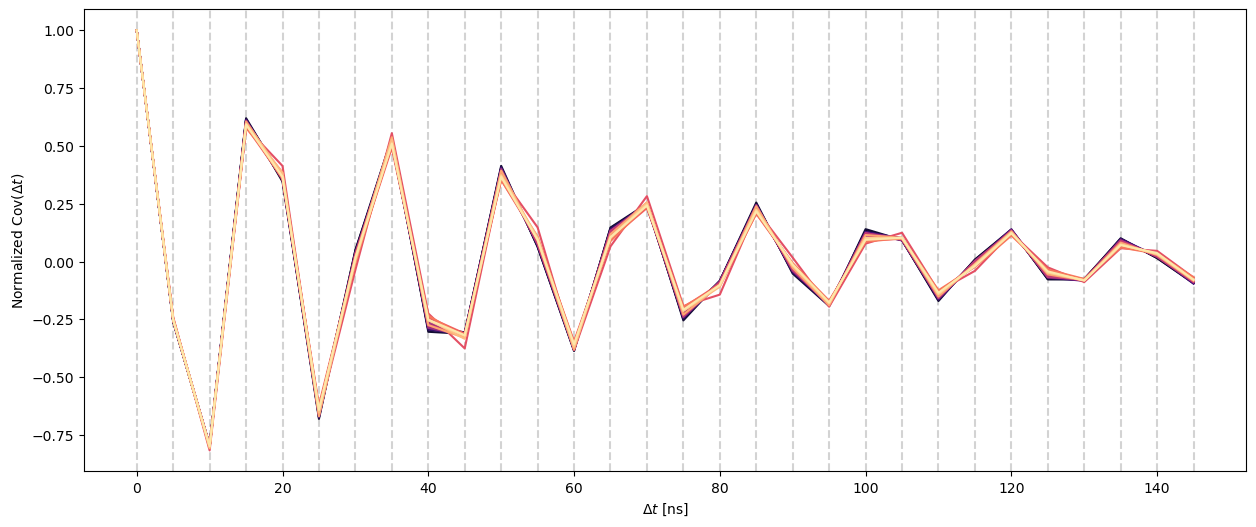

In [259]:
ent = 30
cmap = plt.cm.magma
totn = len(covs)

x = np.arange(ent)*5

plt.figure(figsize=(15,6))
for i in range(ent):
    plt.axvline(i*5, c="lightgray", linestyle="--")

for i in range(len(covs)):
    color = cmap(i/totn)
    plt.plot(x, covs[i, 0, :ent]/covs[i, 0, 0], c=color)

plt.xlabel(r"$\Delta t$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t$)")

plt.show()

In [260]:
from datetime import datetime, timezone

In [261]:
r_times = []
for time in times:
    r_times.append(datetime.fromtimestamp(time, tz=timezone.utc))

In [262]:
r_times

[datetime.datetime(2012, 12, 23, 14, 56, 14, tzinfo=datetime.timezone.utc),
 datetime.datetime(2013, 1, 14, 0, 17, 59, tzinfo=datetime.timezone.utc),
 datetime.datetime(2013, 2, 17, 9, 40, 22, tzinfo=datetime.timezone.utc),
 datetime.datetime(2013, 6, 23, 12, 50, 5, tzinfo=datetime.timezone.utc),
 datetime.datetime(2014, 1, 2, 9, 18, 22, tzinfo=datetime.timezone.utc),
 datetime.datetime(2014, 2, 25, 16, 52, 18, tzinfo=datetime.timezone.utc),
 datetime.datetime(2016, 9, 8, 16, 14, 15, tzinfo=datetime.timezone.utc),
 datetime.datetime(2016, 9, 11, 7, 20, 58, tzinfo=datetime.timezone.utc),
 datetime.datetime(2016, 9, 27, 1, 37, 50, tzinfo=datetime.timezone.utc),
 datetime.datetime(2016, 11, 13, 13, 53, 44, tzinfo=datetime.timezone.utc),
 datetime.datetime(2016, 12, 13, 1, 36, 30, tzinfo=datetime.timezone.utc),
 datetime.datetime(2017, 1, 9, 3, 8, 43, tzinfo=datetime.timezone.utc),
 datetime.datetime(2017, 1, 21, 8, 41, 52, tzinfo=datetime.timezone.utc),
 datetime.datetime(2017, 1, 23, 6, 

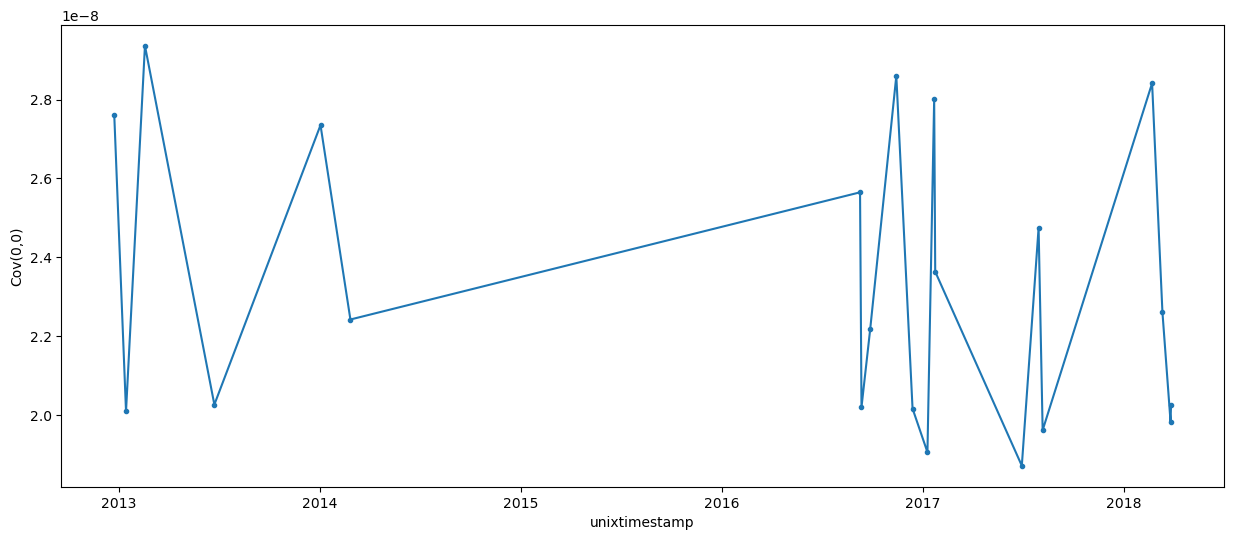

In [263]:
plt.figure(figsize=(15,6))
plt.plot(r_times, covs[:,0,0])
plt.scatter(r_times, covs[:,0,0], marker=".")
plt.xlabel("unixtimestamp")
plt.ylabel("Cov(0,0)")
plt.show()

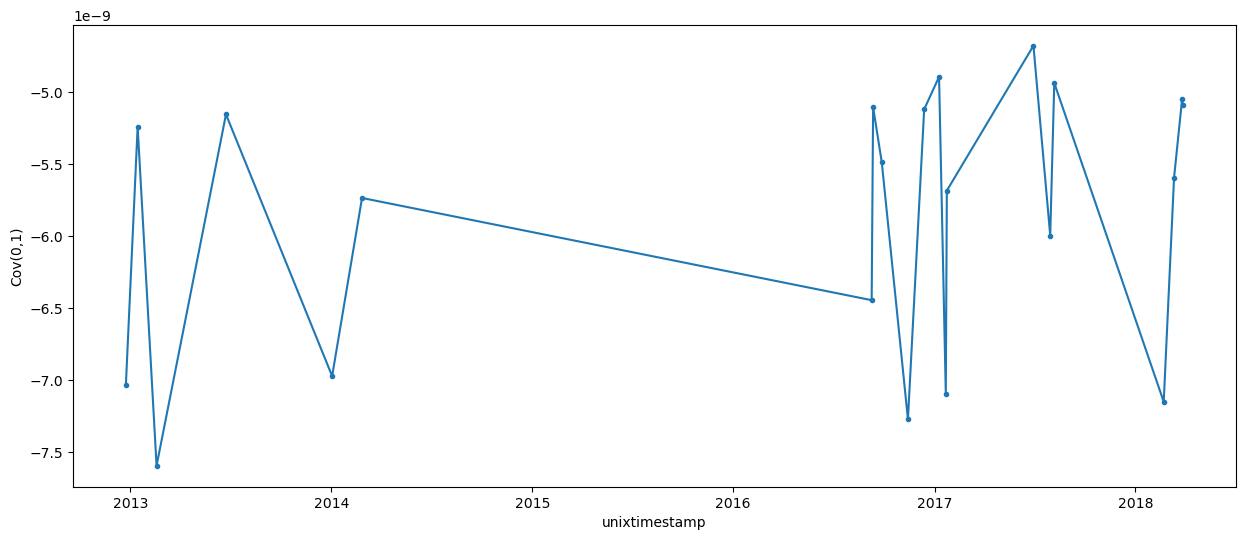

In [264]:
plt.figure(figsize=(15,6))
plt.plot(r_times, covs[:,0,1])
plt.scatter(r_times, covs[:,0,1], marker=".")
plt.xlabel("unixtimestamp")
plt.ylabel("Cov(0,1)")
plt.show()

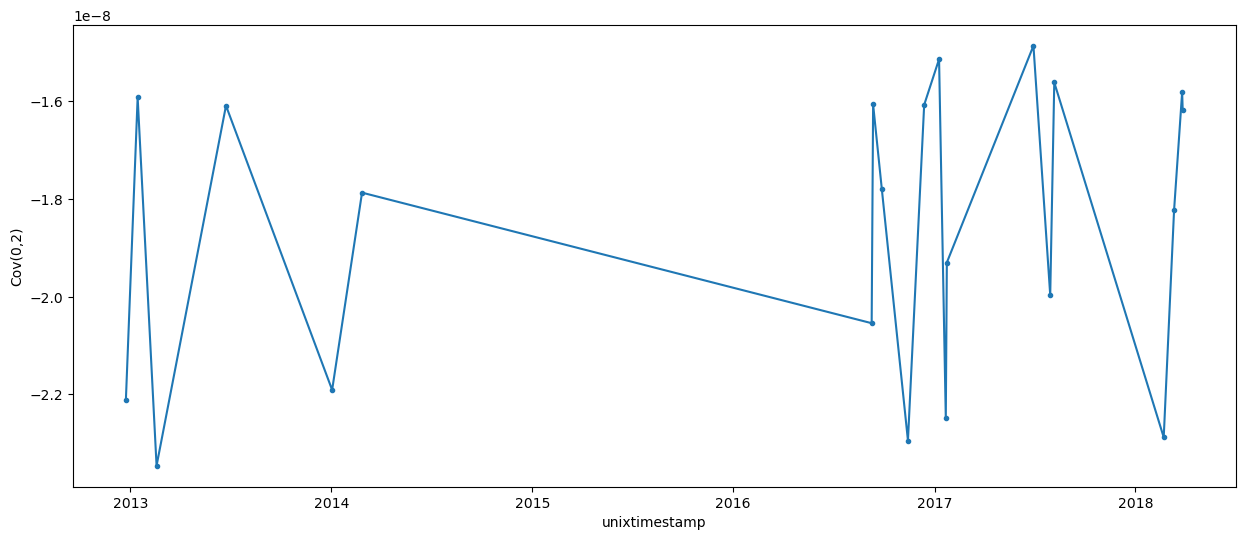

In [265]:
plt.figure(figsize=(15,6))
plt.plot(r_times, covs[:,0,2])
plt.scatter(r_times, covs[:,0,2], marker=".")
plt.xlabel("unixtimestamp")
plt.ylabel("Cov(0,2)")
plt.show()

## Fitting a Model

In [266]:
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

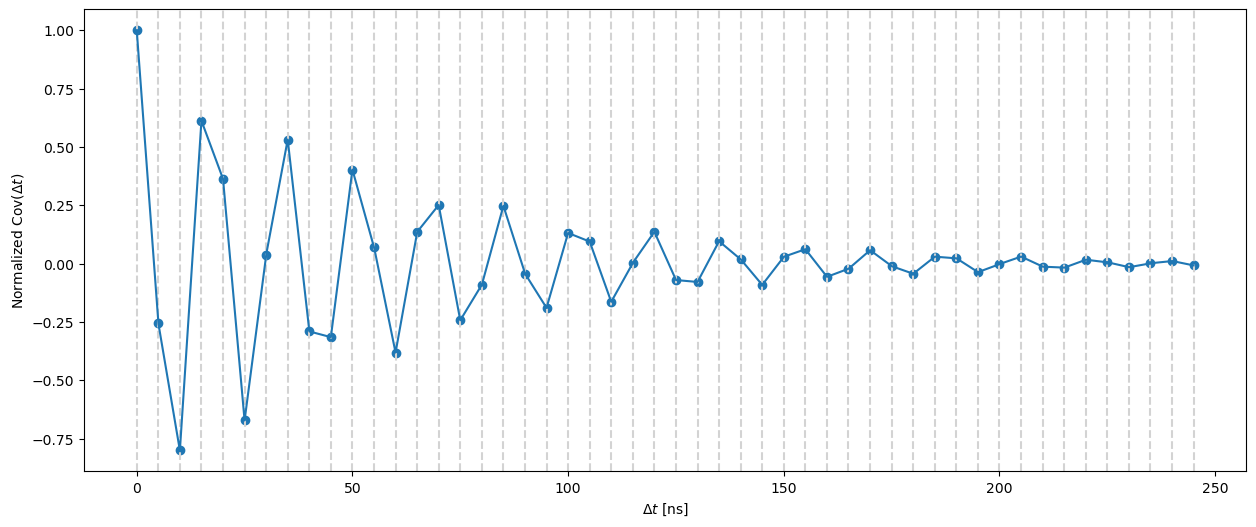

In [267]:
ent = 50
x = np.arange(ent)*5
f = interp1d(x, covs[0,0,:ent]/covs[0,0,0])

x_smooth = np.arange(0, x[-1], 0.01)

plt.figure(figsize=(15,6))
for i in range(ent):
    plt.axvline(i*5, c="lightgray", linestyle="--")

plt.plot(x_smooth, f(x_smooth))
plt.scatter(x, covs[0,0,:ent]/covs[0,0,0])

plt.xlabel(r"$\Delta t$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t$)")

plt.show()

In [268]:
def try_fit(func, ent, step, leg, title, covs, p0=None):
    # start with fitting data
    x = np.arange(ent)*5
    f = interp1d(x, covs[0,0,:ent]/covs[0,0,0]) # interpolation

    x_smooth = np.arange(0, x[-1], step)
    popt, pcov = curve_fit(func, x_smooth, f(x_smooth), p0=p0) #curve_fit
    print(popt)

    unc = np.sqrt(np.diag(pcov))

    string_fn = np.vectorize(lambda x: f"{x:.2f}")
    string_popt = ", ".join(string_fn(popt))
    string_unc = ", ".join(string_fn(unc))

    # calculate statistical measurements
    y = func(x, *popt)
    diff = y-covs[0,0,:ent]/covs[0,0,0]
    rmse = np.sqrt(np.mean(diff**2)) #Root mean square

    n = ent
    k = len(popt)
    RSS = np.sum(diff**2)
    BIC = k*np.log(n) - 2*np.log(RSS/n) # Baysian Information Criterion -- Evaluates loss in info from having parameters. Tends to favor simpler models than AIC.

    #Plots
    cmap = plt.cm.magma
    totn = len(covs)
    y_smooth = func(x_smooth, *popt)

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3,1], "hspace":0})

    # vertical lines
    for j in range(2):
         for i in range(ent):
            axes[j].axvline(i*5, c="lightgray", linestyle="--")

    # first plot
    for i in range(len(covs)):
        color = cmap(i/totn)
        axes[0].plot(x, covs[i, 0, :ent]/covs[i, 0, 0], c=color)

    axes[0].plot(x_smooth, y_smooth, label=f"scipy optimized fit\n"+rf"({leg}) = ({string_popt})"+"\n"+rf"$\delta$({leg}) = ({string_unc})")
    # plt.plot(x_smooth, cos_func(x_smooth, 1, 30, 17.5, 0), color="red")\

    axes[0].set_ylabel(r"Normalized Cov($\Delta t$)")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="gray")
    axes[1].plot(x, diff, label=f"RMSE = {rmse:.2f}\nBIC = {BIC:.2f}")

    axes[1].set_ylabel(r"Residual")
    axes[1].legend()

    plt.xlabel(r"$\Delta t$ [ns]")
    axes[0].set_title(rf"{title}, ent={ent}, step={step}, p0={p0}")

    plt.show()

### damped cosine

In [269]:
def cos_func(x, tau, omega, phi):
    return np.exp(-x/tau)*np.cos(omega*x+phi)
    

[ 4.56953828e+01 -3.67695461e-01 -1.52026873e-02]


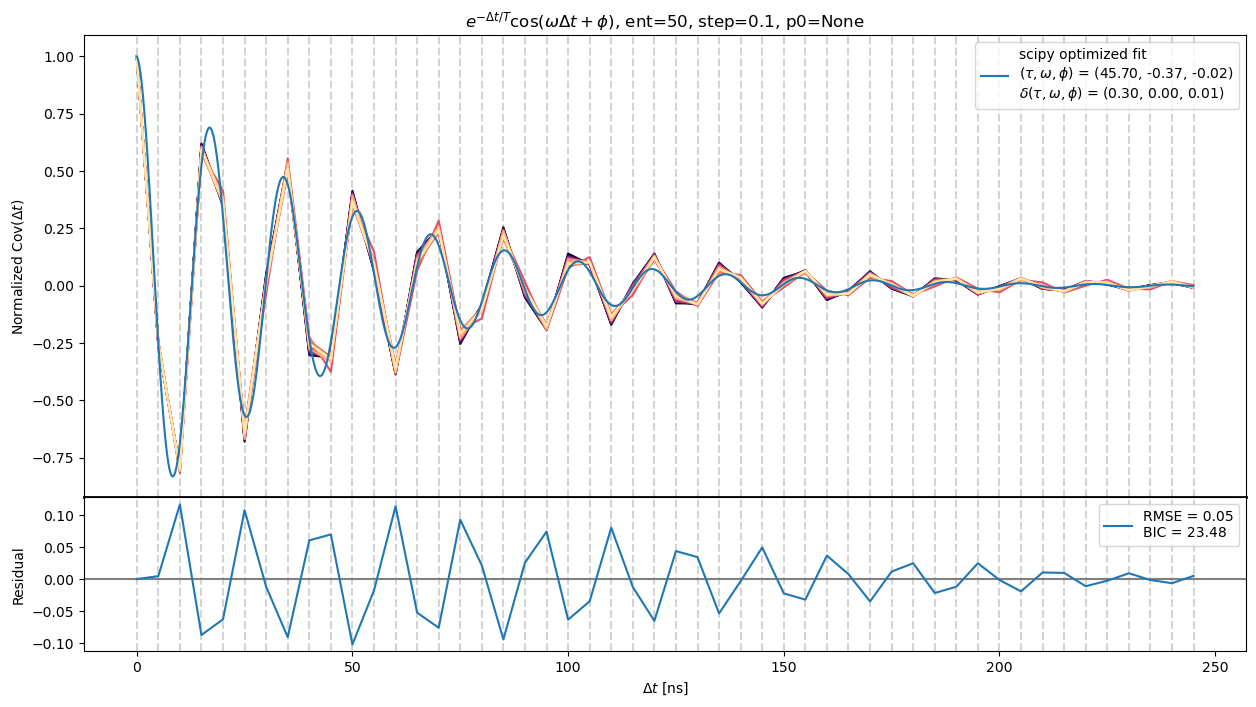

In [270]:
try_fit(cos_func, 50, 0.1, r"$\tau, \omega, \phi$", r"$e^{- \Delta t/T} \cos(\omega \Delta t+ \phi)$", covs)

[ 4.57100592e+01 -3.67705388e-01 -1.49692986e-02]


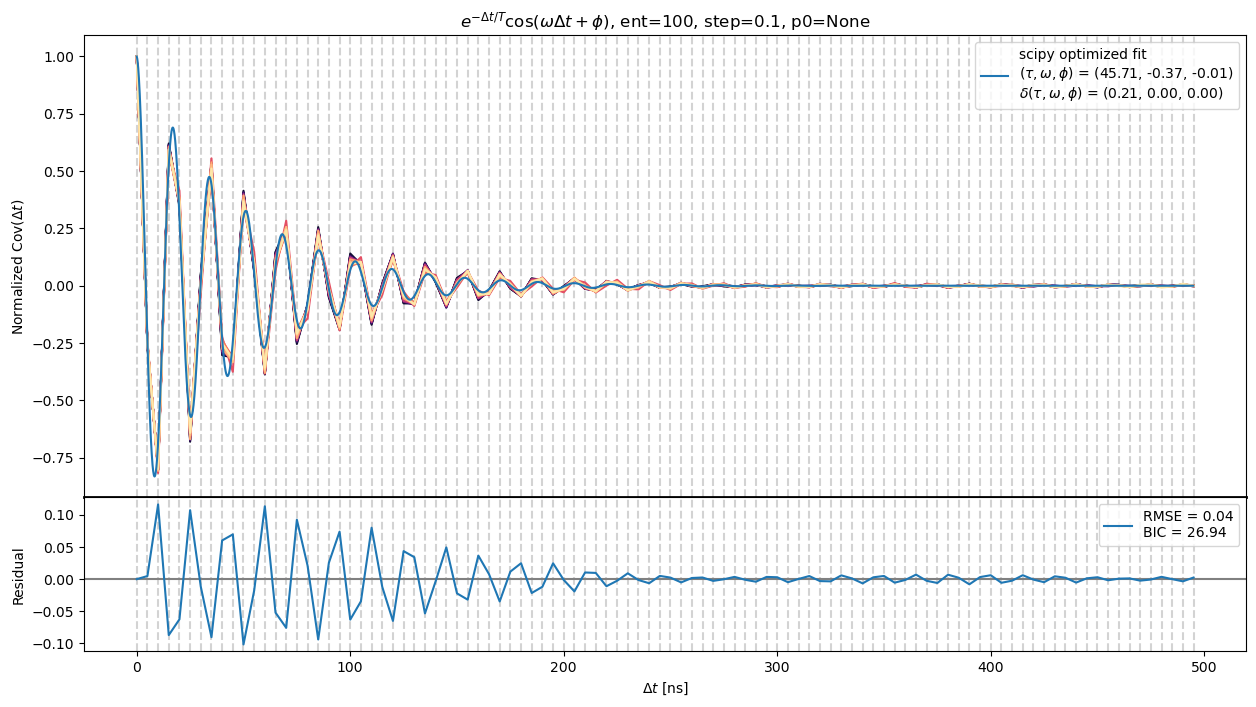

In [271]:
try_fit(cos_func, 100, 0.1, r"$\tau, \omega, \phi$", r"$e^{- \Delta t/T} \cos(\omega \Delta t+ \phi)$", covs)

[ 4.56896624e+01 -3.67695046e-01 -1.52020187e-02]


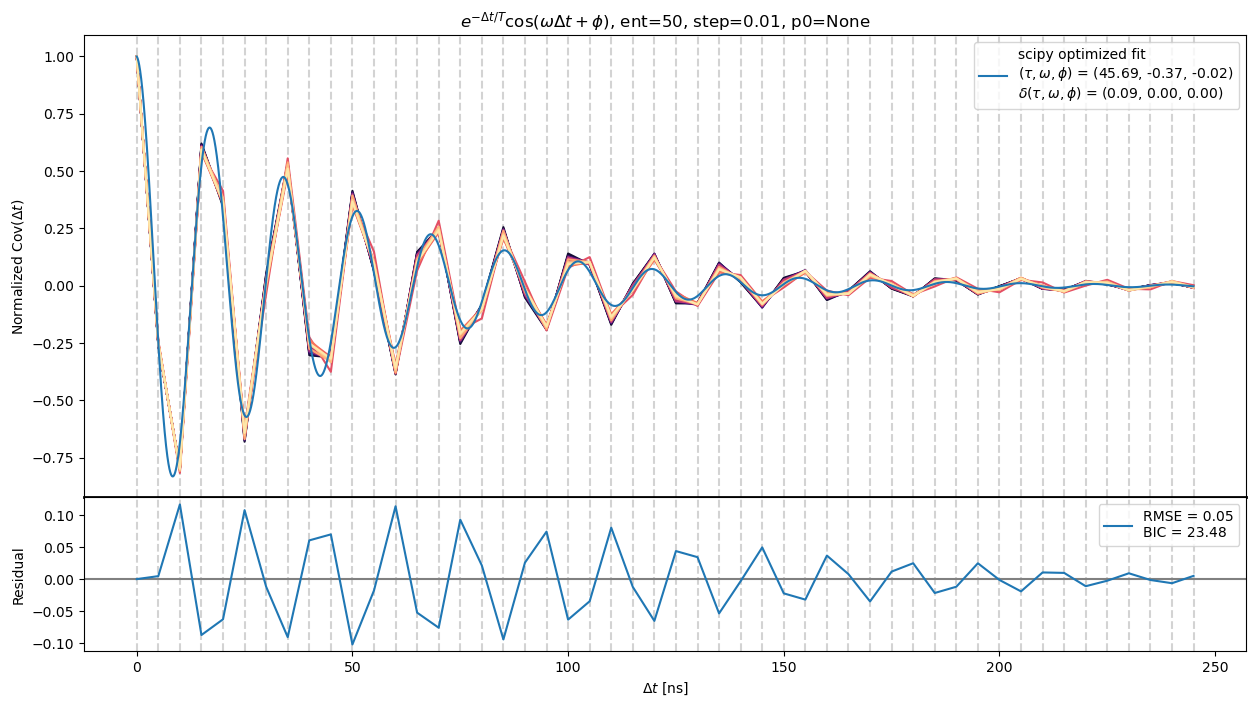

In [272]:
try_fit(cos_func, 50, 0.01, r"$\tau, \omega, \phi$", r"$e^{- \Delta t/T} \cos(\omega \Delta t + \phi)$", covs)

[4.56896039e+01 3.67695303e-01 1.51984914e-02]


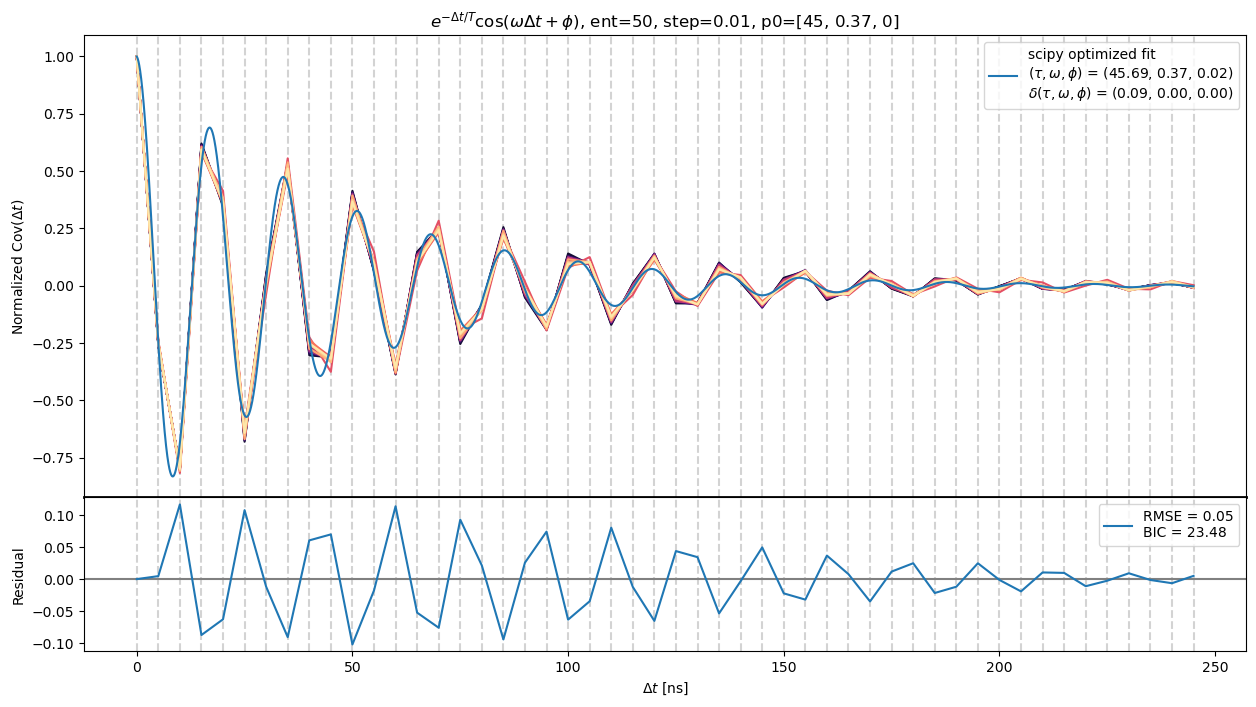

In [273]:
try_fit(cos_func, 50, 0.01, r"$\tau, \omega, \phi$", r"$e^{- \Delta t/T} \cos(\omega \Delta t + \phi)$", covs, p0=[45, 0.37, 0])

[4.51655568e+01 3.67546438e-01 1.84173279e-02]


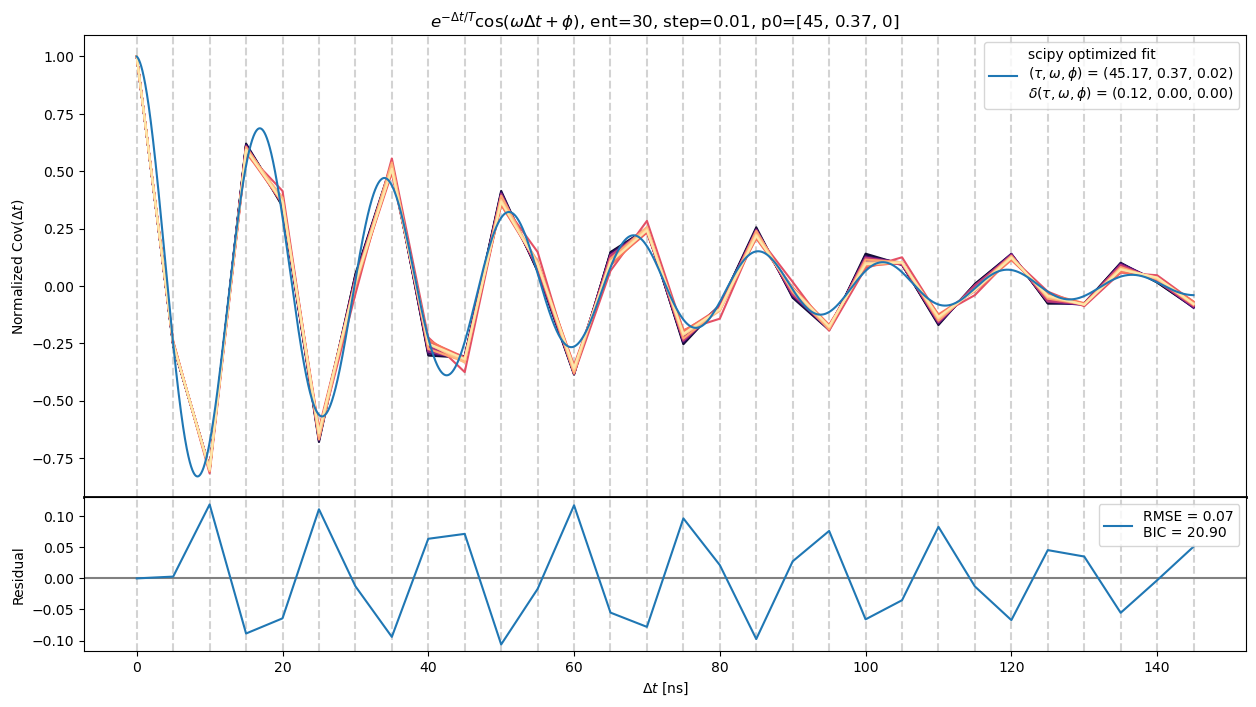

In [274]:
try_fit(cos_func, 30, 0.01, r"$\tau, \omega, \phi$", r"$e^{- \Delta t/T} \cos(\omega \Delta t + \phi)$", covs, p0=[45, 0.37, 0])

### No phase

In [275]:
def cos_nophase_func(x, tau, omega):
    return np.exp(-x/tau)*np.cos(omega*x)

[45.71199548 -0.36799334]


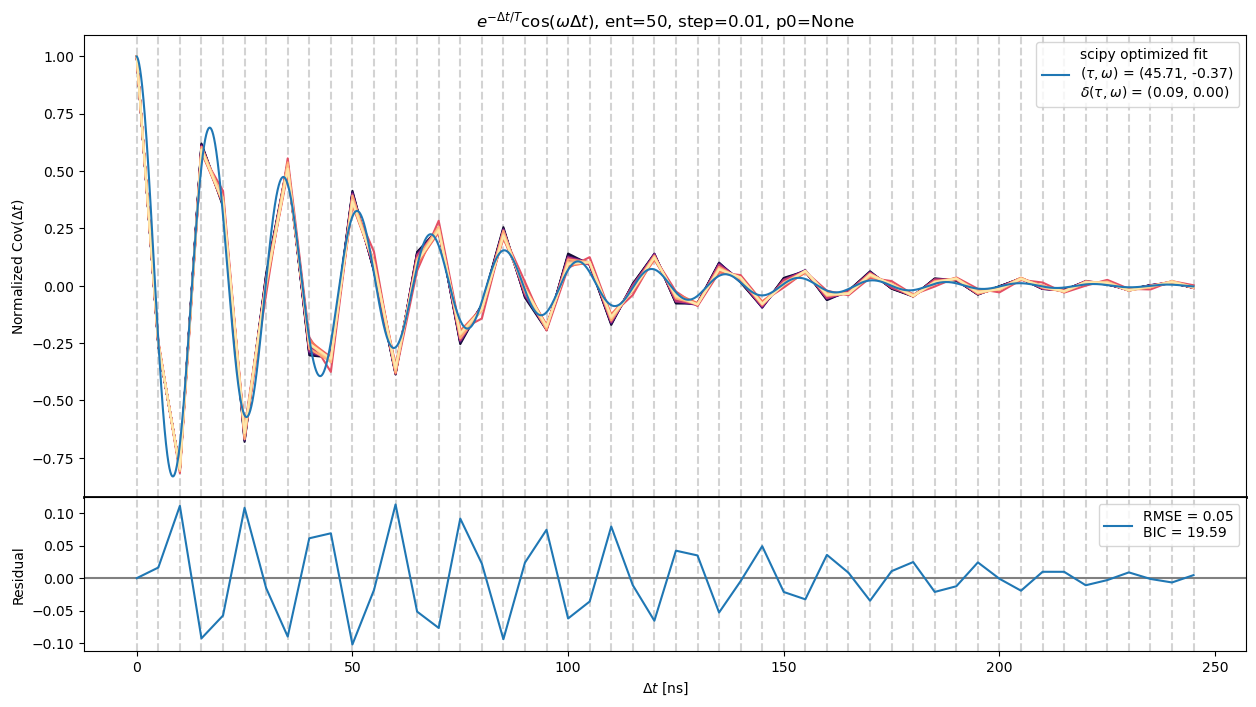

In [276]:
try_fit(cos_nophase_func, 50, 0.01, r"$\tau, \omega$", r"$e^{- \Delta t/T} \cos(\omega \Delta t)$", covs)

### Damping rate set to be free

In [277]:
def cos_freedamp_func(x, alpha, tau, omega, phi):
    return np.exp(-alpha*x/tau)*np.cos(omega*x+phi)

[5.61721730e+07 2.56649587e+09 3.67695203e-01 1.51992531e-02]


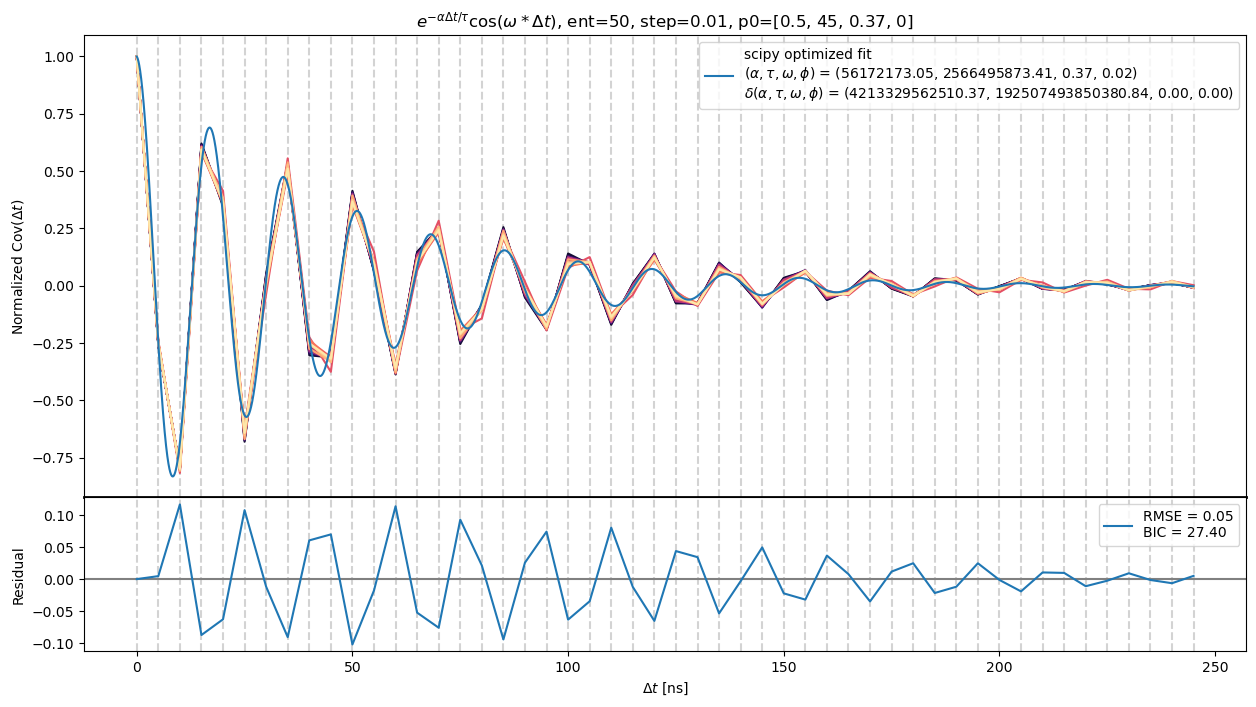

In [278]:
try_fit(cos_freedamp_func, 50, 0.01, r"$\alpha, \tau, \omega, \phi$", r"$e^{- \alpha \Delta t/\tau} \cos (\omega * \Delta t)$", covs, [0.5, 45, 0.37, 0])

### Harmonic

In [279]:
def harm_func(x, tau, A1, A2, A3, omega):
    return np.exp(-x/tau)*(A1*np.cos(omega * x)+A2*np.cos(2*omega*x)+A3*np.cos(3*omega*x))

[5.83566746e+01 7.95718225e-01 1.56150752e-03 7.38915873e-04
 3.68110732e-01]


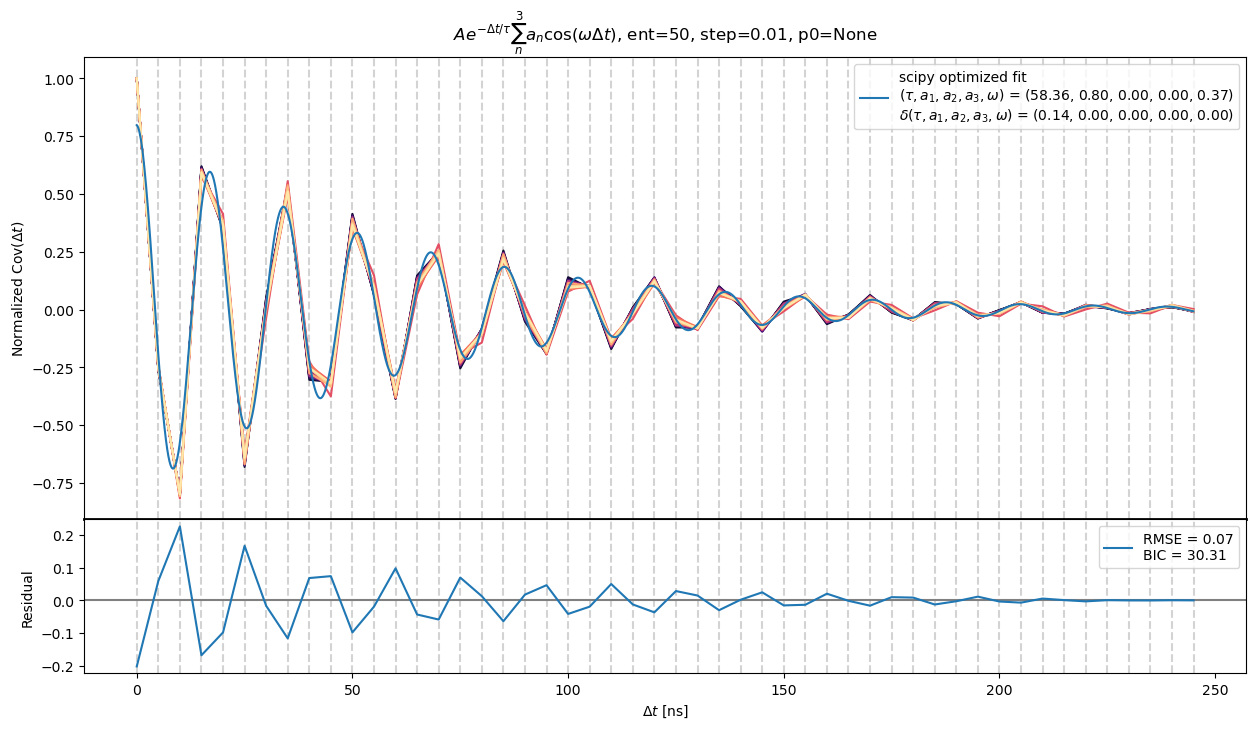

In [280]:
try_fit(harm_func, 50, 0.01, r"$\tau, a_1, a_2, a_3, \omega$", r"$Ae^{- \Delta t/\tau} \sum_n^3 a_n \cos (\omega \Delta t)$", covs)

### Damped sinc

In [281]:
def damped_sinc_func(x, A, tau, omega):
    return A*np.exp(-x/tau)*np.sinc(omega*x)

[7.27231470e-01 4.43921345e+09 1.39059104e-01]


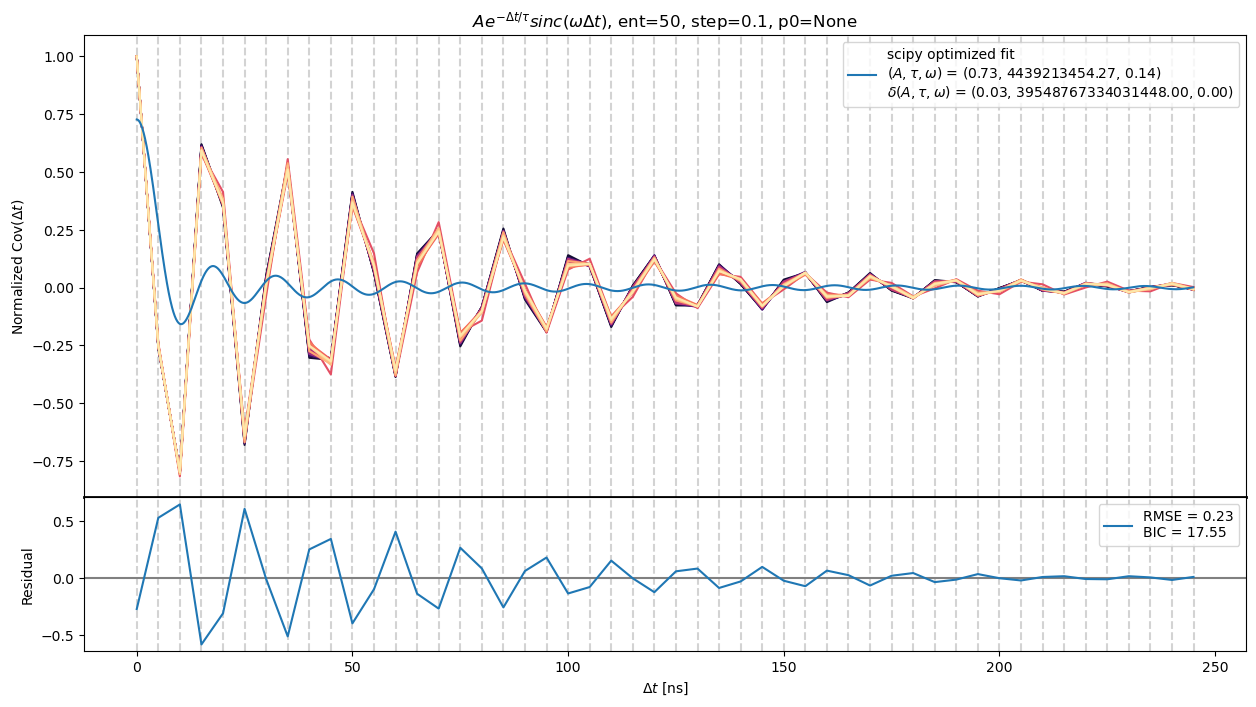

In [282]:
try_fit(damped_sinc_func, 50, 0.1, r"$A, \tau, \omega$", r"$A e^{- \Delta t/\tau} sinc (\omega \Delta t)$", covs)

### sinc function XX

In [283]:
def sinc_func(x, A, omega):
    return A*np.sinc(omega*x)

[0.95088124 0.92160107]


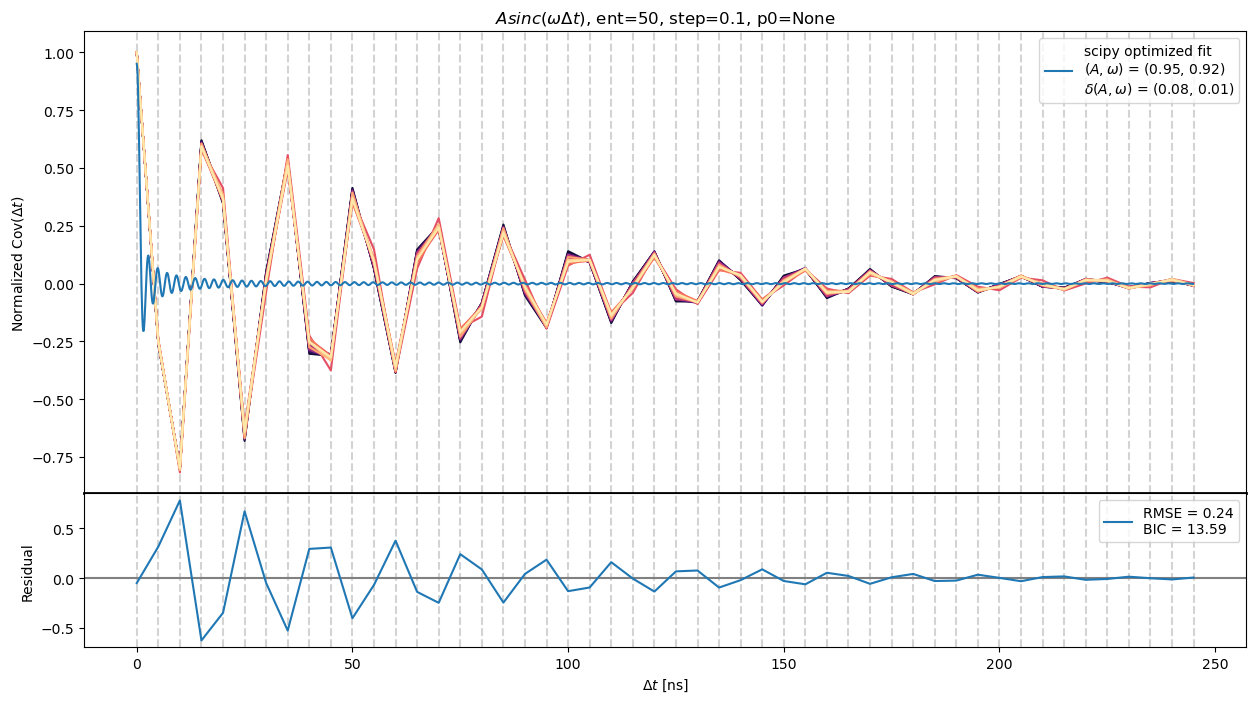

In [284]:
try_fit(sinc_func, 50, 0.1, r"$A, \omega$", r"$A sinc (\omega \Delta t)$", covs)

### Bessel Function XX

In [285]:
from scipy.special import jv

In [286]:
def Bessel_func(x, A, tau, k):
    return A*np.exp(-x/tau)*jv(0,k*x)

## Fourier Space

In [287]:
from scipy import fft

In [288]:
data = covs[0, 0]
N = len(data)
dt = 5*10**(-9)
fourier = fft.rfft(data)
nu = np.sqrt(2)*dt*fourier
omega = 2*np.pi * np.fft.rfftfreq(N, d=dt)

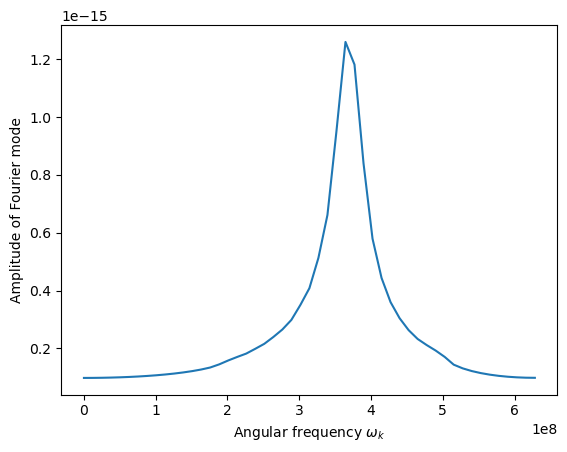

In [289]:
plt.plot(omega, np.abs(nu))
plt.ylabel("Amplitude of Fourier mode")
plt.xlabel(r"Angular frequency $\omega_k$")
plt.show()

In [442]:
# For all events
N = len(covs[0,0])
dt = 5*10**(-9)
fouriers = []
omegas = []
for cov in covs:
    fouriers.append(np.sqrt(2)*dt*fft.rfft(cov[0]))
fouriers = np.array(fouriers)

omega = np.fft.rfftfreq(N, d=dt)/1e+8

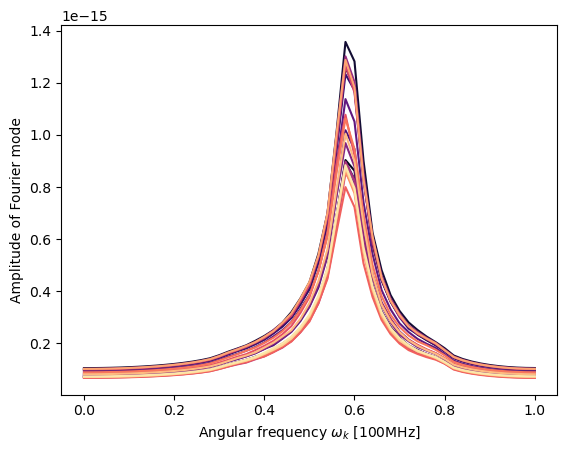

In [455]:
cmap = plt.cm.magma
totn = len(fouriers)
for i in range(totn):
    color=cmap(i/totn)
    plt.plot(omega, np.abs(fouriers[i]), c=color)

plt.ylabel("Amplitude of Fourier mode")
plt.xlabel(r"Angular frequency $\omega_k$ [100MHz]")
plt.show()

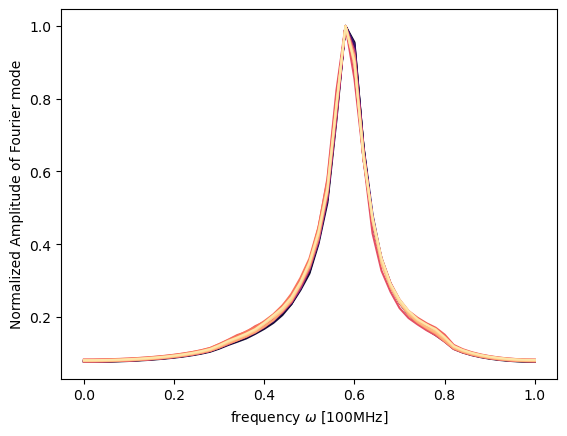

In [456]:
cmap = plt.cm.magma
totn = len(fouriers)
for i in range(totn):
    color=cmap(i/totn)
    plt.plot(omega, np.abs(fouriers[i])/np.max(np.abs(fouriers[i])), c=color)

plt.ylabel("Normalized Amplitude of Fourier mode")
plt.xlabel(r"frequency $\omega$ [100MHz]")
plt.show()

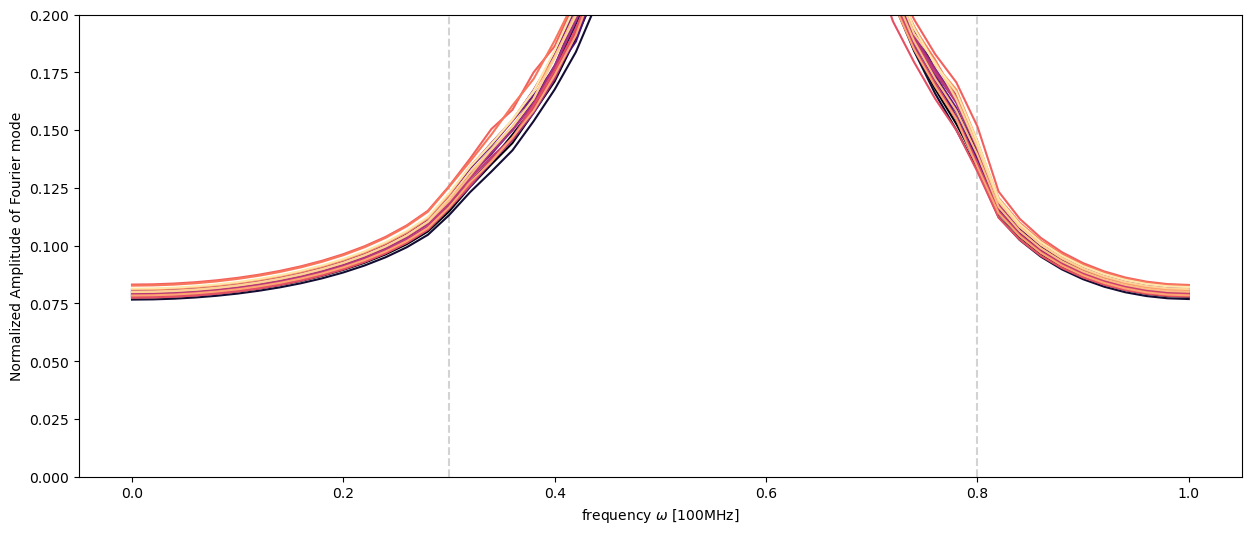

In [457]:
cmap = plt.cm.magma
totn = len(fouriers)
plt.figure(figsize=(15, 6))
plt.axvline(x=0.3, c="lightgray", linestyle="--")
plt.axvline(x=0.8, c="lightgray", linestyle="--")
for i in range(totn):
    color=cmap(i/totn)
    plt.plot(omega, np.abs(fouriers[i])/np.max(np.abs(fouriers[i])), c=color)

plt.ylabel("Normalized Amplitude of Fourier mode")
plt.xlabel(r"frequency $\omega$ [100MHz]")
plt.ylim(0,0.2)
plt.show()

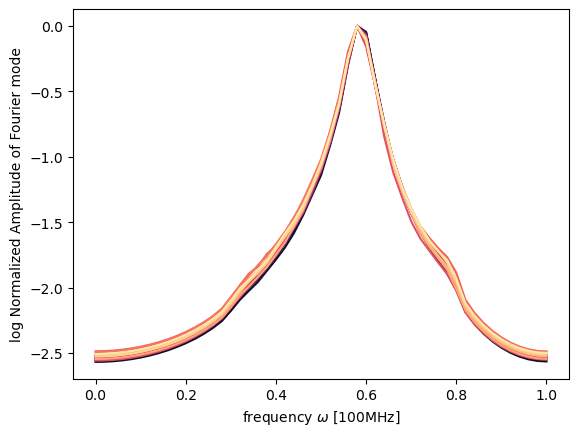

In [458]:
cmap = plt.cm.magma
totn = len(fouriers)
for i in range(totn):
    color=cmap(i/totn)
    plt.plot(omega, np.log(np.abs(fouriers[i])/np.max(np.abs(fouriers[i]))), c=color)

plt.ylabel("log Normalized Amplitude of Fourier mode")
plt.xlabel(r"frequency $\omega$ [100MHz]")
plt.show()

In [459]:
def try_fit_freq(func, leg, title, fouriers, omega, p0=None, bounds=(-np.inf, np.inf), maxnum=10000):
    # start with fitting data
    y_true = np.abs(fouriers[0]/np.max(fouriers[0]))
    popt, pcov = curve_fit(func, omega, y_true, p0=p0, bounds=bounds, maxfev=maxnum) #curve_fit
    print(popt)

    unc = np.sqrt(np.diag(pcov))

    string_fn = np.vectorize(lambda x: f"{x:.3g}")
    string_popt = ", ".join(string_fn(popt))
    string_unc = ", ".join(string_fn(unc))
    if p0 ==None:
        string_p0 = "None"
    else:
        string_p0 = ", ".join(string_fn(p0))

    # calculate statistical measurements
    y = func(omega, *popt)
    diff = y-y_true
    rmse = np.sqrt(np.mean(diff**2)) #Root mean square

    n = len(y)
    k = len(popt)
    RSS = np.sum(diff**2)
    BIC = k*np.log(n) - 2*np.log(RSS/n) # Baysian Information Criterion -- Evaluates loss in info from having parameters. Tends to favor simpler models than AIC.

    #Plots
    cmap = plt.cm.magma
    totn = len(fouriers)

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [2,1], "hspace":0})

    # first plot
    for i in range(totn):
        color = cmap(i/totn)
        axes[0].plot(omega, np.abs(fouriers[i]/np.max(fouriers[i])) , c=color)

    axes[0].plot(omega, y, label=f"scipy optimized fit\n"+rf"({leg}) = ({string_popt})"+"\n"+rf"$\delta$({leg}) = ({string_unc})")
    # plt.plot(x_smooth, cos_func(x_smooth, 1, 30, 17.5, 0), color="red")\

    axes[0].set_ylabel(r"Normalized Fourier Amplitude of Cov($\Delta t$)")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="gray")
    axes[1].plot(omega, diff, label=f"RMSE = {rmse:.2f}\nBIC = {BIC:.2f}")

    axes[1].set_ylabel(r"Residual")
    axes[1].legend()

    plt.xlabel(r"$\omega$ [100MHz]")
    axes[0].set_title(rf"{title}, p0=[{string_p0}]")

    plt.show()

### Lorentzian

In [451]:
def Lorentzian(x, A, gamma, omega0, C):
    return A*(gamma**2/((x-omega0)**2 + gamma**2)+C)

[ 0.90189933 -0.04923773  0.58599459  0.09166779]


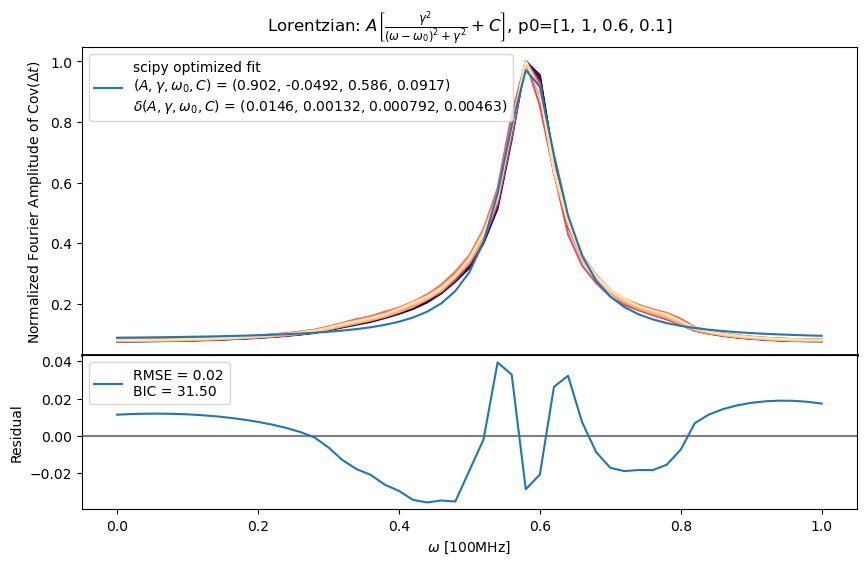

In [460]:
try_fit_freq(Lorentzian, r"$A, \gamma, \omega_0, C$", r"Lorentzian: $A \left[\frac{\gamma^2}{(\omega- \omega_0)^2 + \gamma^2}+C \right]$", fouriers, omega, 
             p0=[1, 1, 0.6, 0.1])

### General Lorentzian  OOO

In [378]:
def General_Lorentzian(x, A, omega0, gamma, p, C):
    return np.abs(A*(1/(1+(np.abs(x-omega0)/gamma)**(2*p))+C))

[0.90189876 0.58599458 0.04923783 1.         0.09166769]


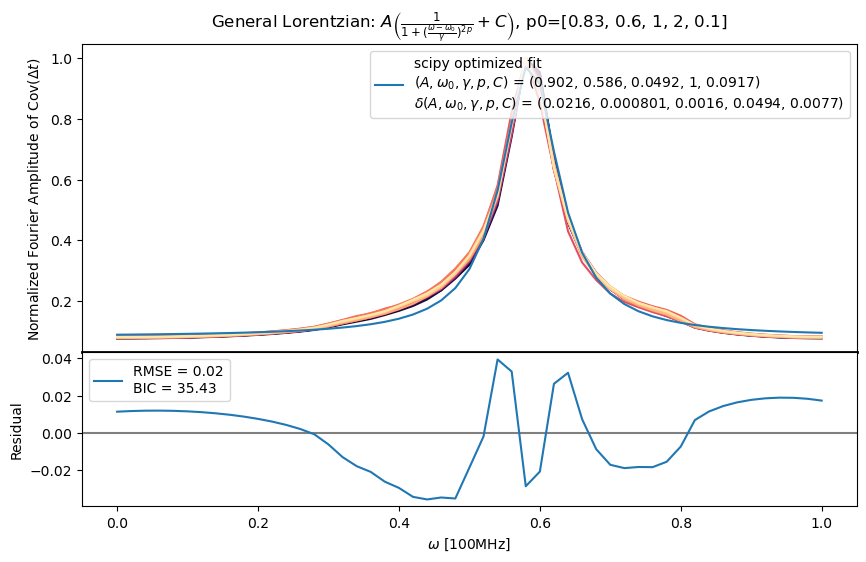

In [461]:
lower=[0,0,0,1, 0]
upper=[np.inf, np.inf, np.inf, 10, 1]
try_fit_freq(General_Lorentzian, r"$A, \omega_0, \gamma, p, C$", r"General Lorentzian: $A \left( \frac{1}{1+(\frac{\omega- \omega_0}{\gamma})^{2p}}+C \right)$", 
             fouriers, omega, p0=[0.83,0.6,1,2, 0.1], bounds=(lower, upper))

### Gaussian

In [351]:
def Gaussian(x, A, omega0, sigma, C):
    return A*(np.exp(-(x-omega0)**2/(2*sigma**2))+C)

[ 0.78075932  0.58571299 -0.04929469  0.14889043]


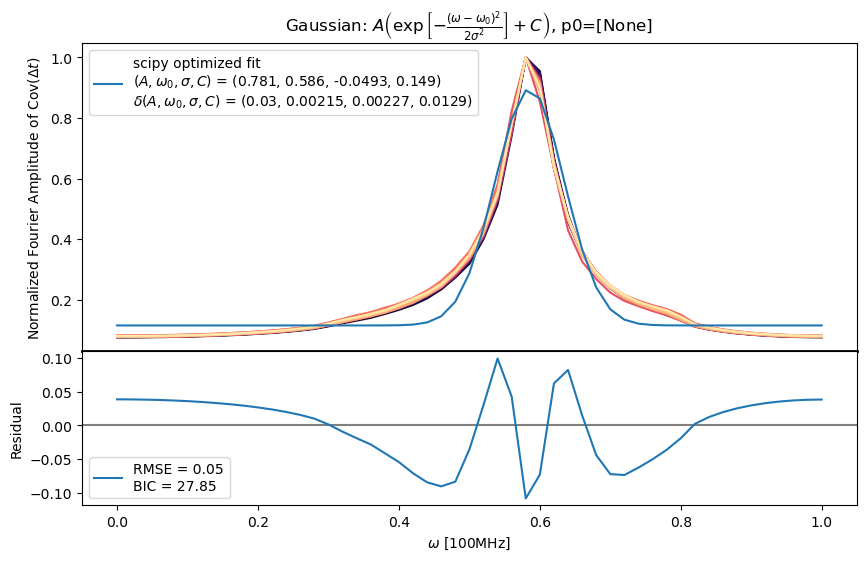

In [462]:
try_fit_freq(Gaussian, r"$A, \omega_0, \sigma, C$", r"Gaussian: $A \left( \exp \left[- \frac{(\omega-\omega_0)^2}{2 \sigma^2} \right]+C \right)$", fouriers, omega)

### Voigt Profile

In [312]:
from scipy.special import voigt_profile

In [353]:
def Voigit(x, A, omega0, sigma, gamma, C):
    return A*(voigt_profile(x-omega0, sigma, gamma)+C)

[-1.32223752e-01  5.86054047e-01 -3.43010527e-08 -4.66371026e-02
 -6.75270200e-01]


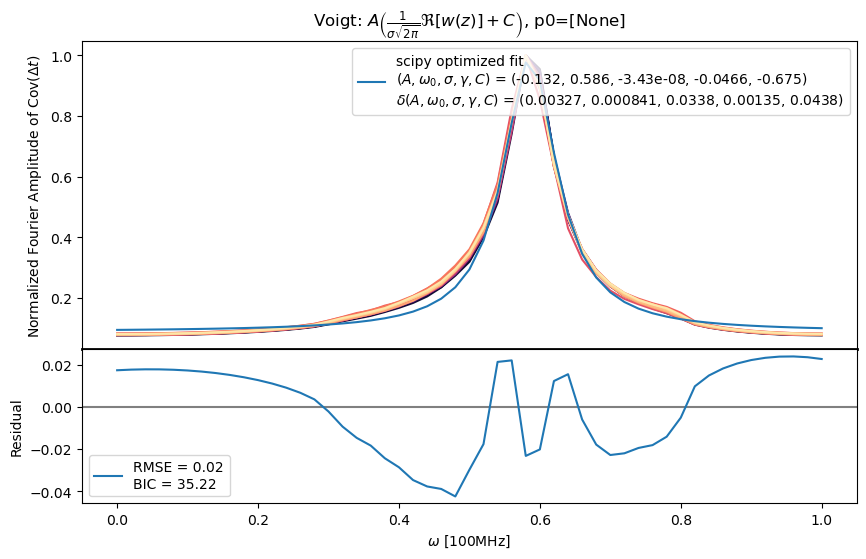

In [463]:
try_fit_freq(Voigit, r"$A, \omega_0, \sigma, \gamma, C$", r"Voigt: $A \left( \frac{1}{\sigma \sqrt{2 \pi}} \Re [w(z)] +C \right)$", fouriers, omega)

### Super Gaussian XX

In [356]:
def super_Gaussian(x, A, omega0, sigma, m, C):
    return A*(np.exp(-((x-omega0)/sigma)**(2*m))+C)

/tmp/ipykernel_13988/3906863686.py:2: RuntimeWarning: invalid value encountered in power
  return A*(np.exp(-((x-omega0)/sigma)**(2*m))+C)
/tmp/ipykernel_13988/500729502.py:5: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, omegas[0], y_true, p0=p0, bounds=bounds, maxfev=10000) #curve_fit


[1.  0.6 1.  0.8 0.1]


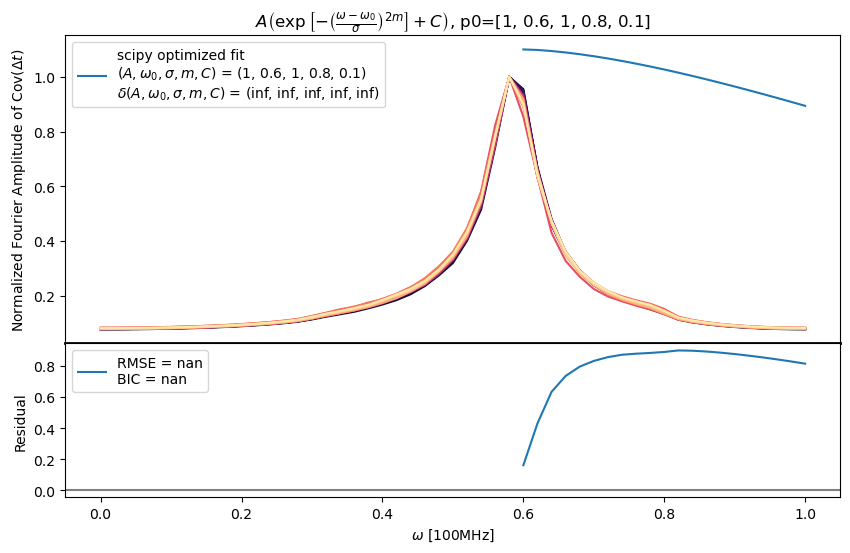

In [360]:
try_fit_freq(super_Gaussian, r"$A, \omega_0, \sigma, m, C$", r"$A \left( \exp \left[- \left( \frac{\omega-\omega_0}{\sigma} \right)^{2m} \right] +C \right)$", 
             fouriers, p0=[1,0.6, 1, 0.8, 0.1])

### Pearson VII

In [361]:
def Pearson_VII(x, A, omega0, gamma, m, C):
    return A*((1+((x-omega0)/gamma)**2)**(-m)+C)

[ 1.00055666  0.58612145 -0.02950015  0.55516211  0.03084584]


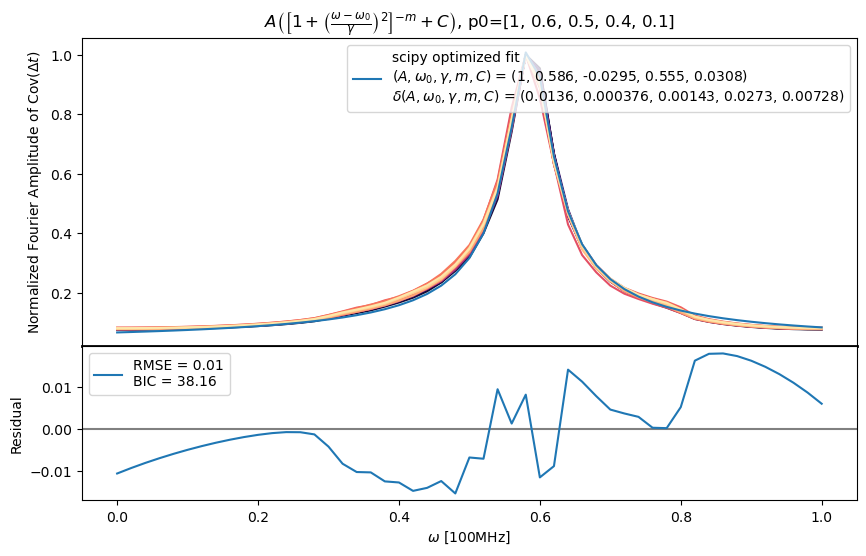

In [464]:
try_fit_freq(Pearson_VII, r"$A, \omega_0, \gamma, m, C$", r"$A \left( \left[ 1+ \left( \frac{\omega - \omega_0}{\gamma} \right) ^2 \right] ^{-m} +C \right)$",
             fouriers, omega, p0=[1, 0.6, 0.5, 0.4, 0.1])

[ 1.00055649  0.58612145 -0.02950017  0.55516244  0.03084591]


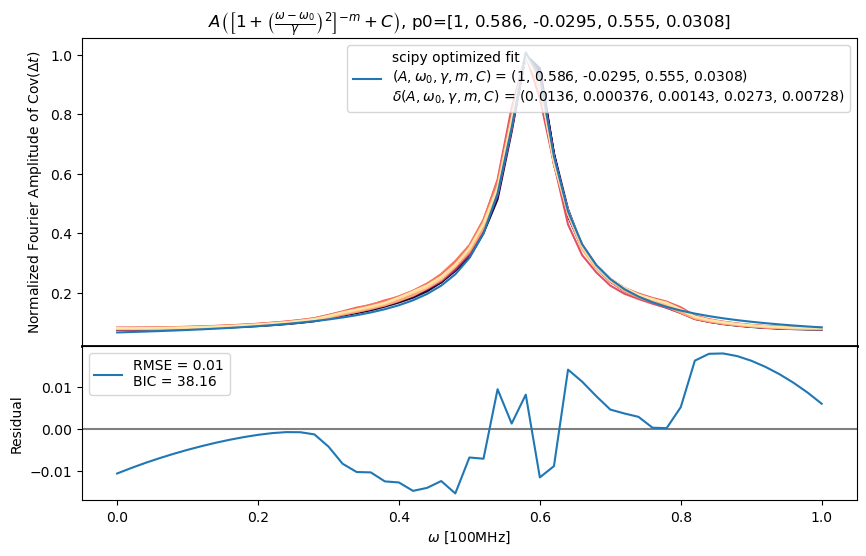

In [465]:
try_fit_freq(Pearson_VII, r"$A, \omega_0, \gamma, m, C$", r"$A \left( \left[ 1+ \left( \frac{\omega - \omega_0}{\gamma} \right) ^2 \right] ^{-m} +C \right)$",
             fouriers, omega, p0= [1.00055666,0.58612145,-0.02950015,0.55516211,0.03084584])

## Inverse Fourier

In [ ]:
def fit_freq_adv(func, leg, title, fouriers, omega, covs, ent, p0=None, bounds=(-np.inf, np.inf), maxnum=10000):
    # start with fitting data
    y_true = np.abs(fouriers[0]/np.max(fouriers[0]))
    popt, pcov = curve_fit(func, omega, y_true, p0=p0, bounds=bounds, maxfev=maxnum) #curve_fit
    print(popt)

    unc = np.sqrt(np.diag(pcov))

    string_fn = np.vectorize(lambda x: f"{x:.3g}")
    string_popt = ", ".join(string_fn(popt))
    string_unc = ", ".join(string_fn(unc))
    if p0 ==None:
        string_p0 = "None"
    else:
        string_p0 = ", ".join(string_fn(p0))

    # calculate statistical measurements
    y = func(omega, *popt)
    diff = y-y_true
    rmse = np.sqrt(np.mean(diff**2)) #Root mean square

    n = len(y)
    k = len(popt)
    RSS = np.sum(diff**2)
    BIC = k*np.log(n) - 2*np.log(RSS/n) # Baysian Information Criterion -- Evaluates loss in info from having parameters. Tends to favor simpler models than AIC.

    #Plots
    cmap = plt.cm.magma
    totn = len(fouriers)

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [2,1], "hspace":0})

    # first plot
    for i in range(totn):
        color = cmap(i/totn)
        axes[0].plot(omega, np.abs(fouriers[i]/np.max(fouriers[i])) , c=color)

    axes[0].plot(omega, y, label=f"scipy optimized fit\n"+rf"({leg}) = ({string_popt})"+"\n"+rf"$\delta$({leg}) = ({string_unc})")
    # plt.plot(x_smooth, cos_func(x_smooth, 1, 30, 17.5, 0), color="red")\

    axes[0].set_ylabel(r"Normalized Fourier Amplitude of Cov($\Delta t$)")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="gray")
    axes[1].plot(omega, diff, label=f"RMSE = {rmse:.2f}\nBIC = {BIC:.2f}")

    axes[1].set_ylabel(r"Residual")
    axes[1].legend()

    plt.xlabel(r"$\omega$ [100MHz]")
    axes[0].set_title(rf"{title}, p0=[{string_p0}]")

    plt.show()

    # plt.figure(figsize=(10,2)) #gamma second, omega_0 third!
    # norm_x = (x-popt[2])/popt[1]
    # plt.plot(norm_x, diff)
    # plt.xlabel(r"Normalized $x=\frac{\omega-\omega_0}{\gamma}$")
    # plt.ylabel("Residual")
    # plt.show()

    # data = covs[0, 0]
    # N = len(data)
    # time_y = fft.irfft(y, N)

    time_y = fft.irfft(y)

    norm_time_y = time_y[:ent]/np.max(time_y)

    diff = norm_time_y-covs[0,0,:ent]/covs[0,0,0]
    rmse = np.sqrt(np.mean(diff**2)) #Root mean square

    time_x = np.arange(ent)*5

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3,1], "hspace":0})

    # vertical lines
    for j in range(2):
        for i in range(ent):
            axes[j].axvline(i*5, c="lightgray", linestyle="--")

    # first plot
    for i in range(len(covs)):
        color = cmap(i/totn)
        axes[0].plot(time_x, covs[i, 0, :ent]/covs[i, 0, 0], c=color)

    axes[0].plot(time_x, norm_time_y, label="Inverse Fourier")

    axes[0].set_ylabel(r"Normalized Cov($\Delta t$)")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="gray")
    axes[1].plot(time_x, diff, label=f"RMSE = {rmse:.2f}")

    axes[1].set_ylabel(r"Residual")
    axes[1].legend()

    plt.xlabel(r"$\Delta t$ [ns]")
    axes[0].set_title(rf"{title}, ent={ent}")

    plt.show()

    return popt, pcov, time_y

### Pearson VII

[ 1.00055649  0.58612145 -0.02950017  0.55516244  0.03084591]


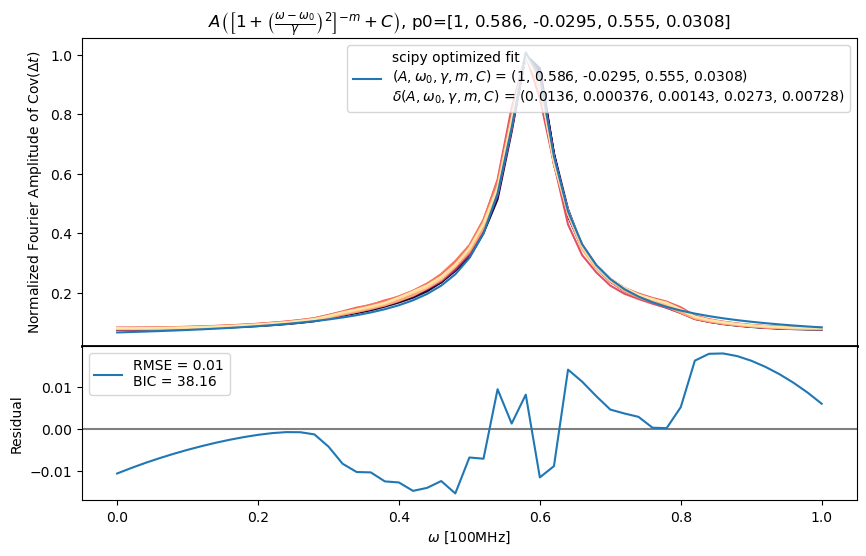

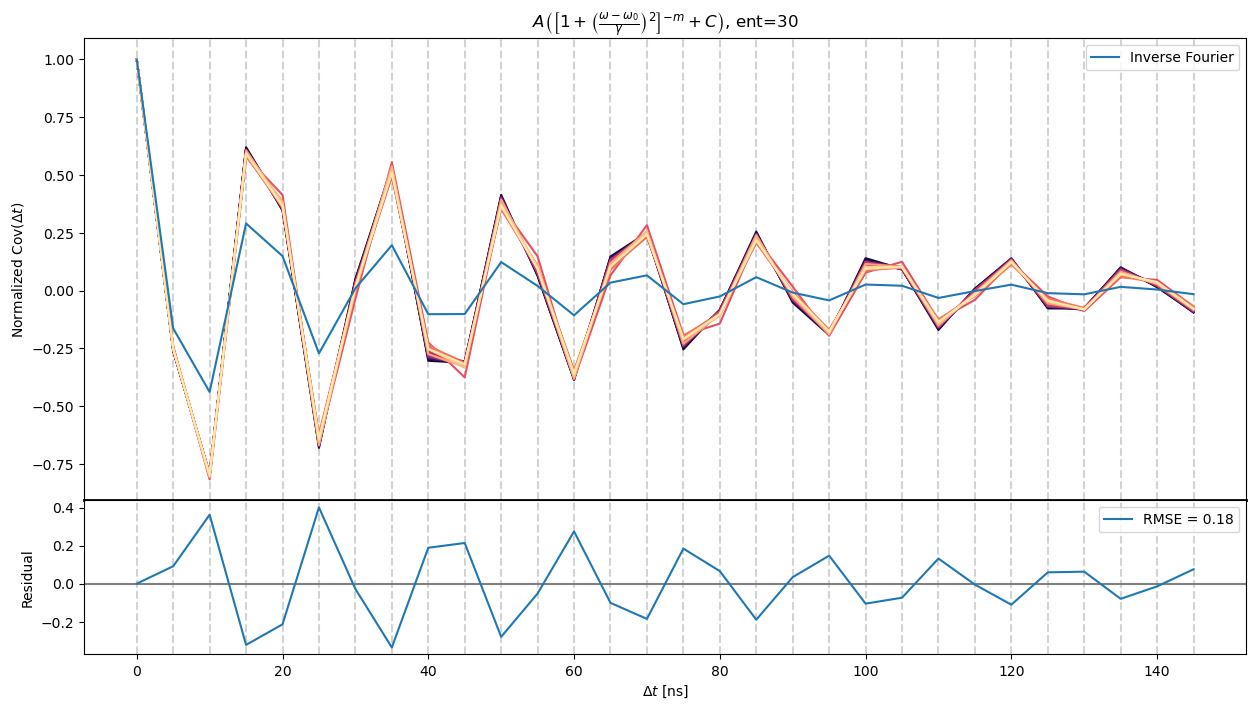

In [ ]:
res = fit_freq_adv(Pearson_VII, r"$A, \omega_0, \gamma, m, C$", r"$A \left( \left[ 1+ \left( \frac{\omega - \omega_0}{\gamma} \right) ^2 \right] ^{-m} +C \right)$",
             fouriers, omega, covs, 30, p0= [1.00055666,0.58612145,-0.02950015,0.55516211,0.03084584])

### General Lorentzian

[0.90189876 0.58599458 0.04923783 1.         0.09166769]


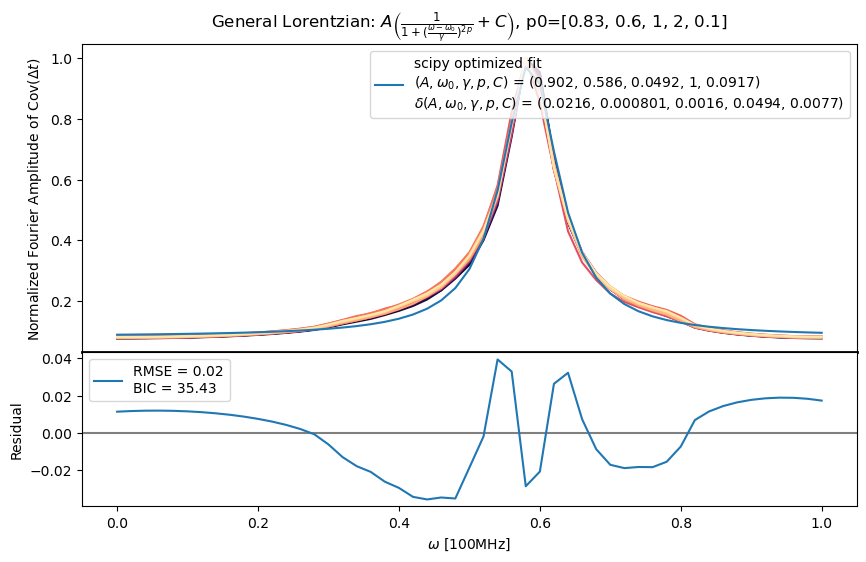

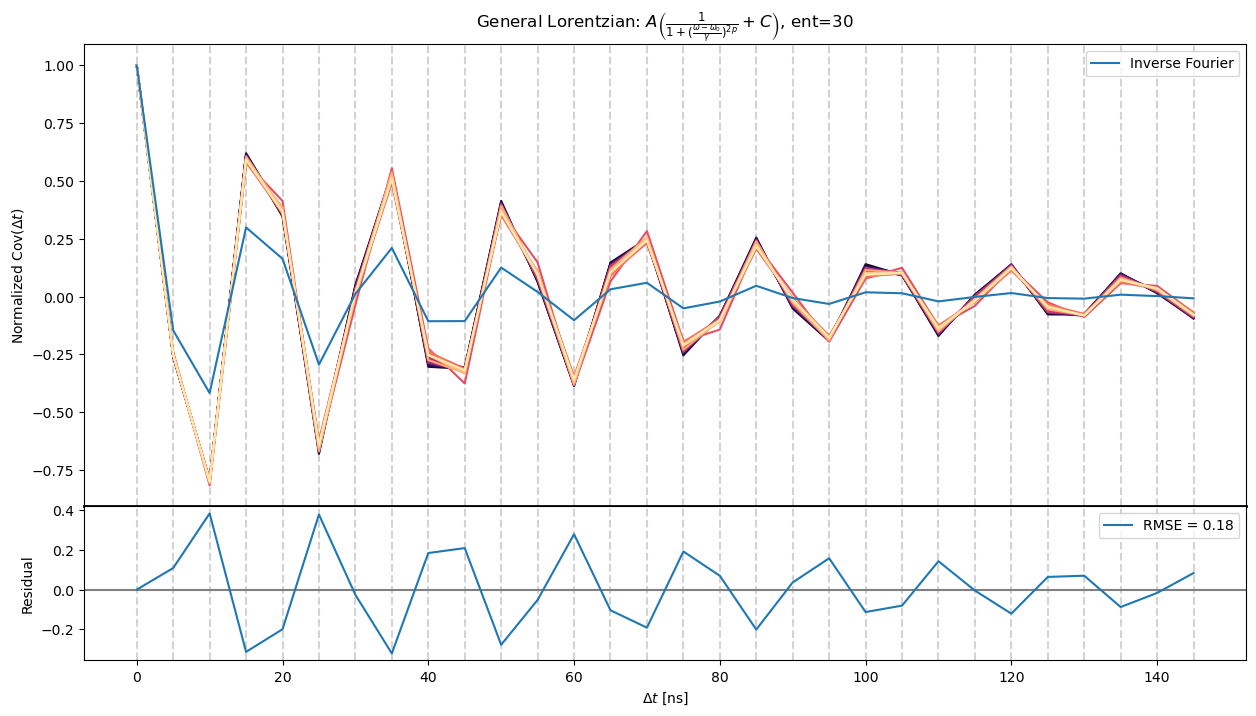

In [ ]:
lower=[0,0,0,1, 0]
upper=[np.inf, np.inf, np.inf, 10, 1]
res = fit_freq_adv(General_Lorentzian, r"$A, \omega_0, \gamma, p, C$", r"General Lorentzian: $A \left( \frac{1}{1+(\frac{\omega- \omega_0}{\gamma})^{2p}}+C \right)$", 
             fouriers, omega, covs, 30, p0=[0.83,0.6,1,2, 0.1], bounds=(lower, upper))

## Fourier from Interp1d-ed Cov

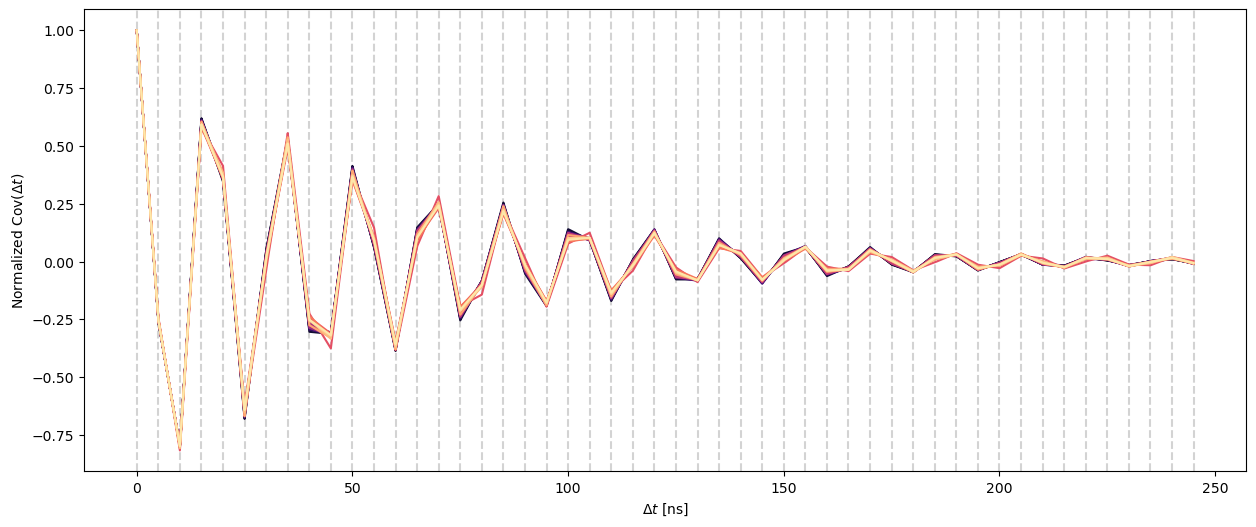

In [468]:
ent = 50
x = np.arange(ent)*5
x_smooth = np.arange(0, x[-1], 0.01)
ys = []

for cov in covs:
    f = interp1d(x, cov[0,:ent]/cov[0,0])
    ys.append(f(x_smooth))

cmap = plt.cm.magma
totn = len(ys)

plt.figure(figsize=(15,6))
for i in range(ent):
    plt.axvline(i*5, c="lightgray", linestyle="--")

for i in range(totn):
    color = cmap(i/totn)
    plt.plot(x_smooth, ys[i], c=color)
# plt.scatter(x, covs[0,0,:ent]/covs[0,0,0], marker=".")

plt.xlabel(r"$\Delta t$ [ns]")
plt.ylabel(r"Normalized Cov($\Delta t$)")

plt.show()

In [ ]:
x_smoot

np.float64(1.0000408179925712e-11)

In [481]:
N = len(ys[0])
dt = 0.01*10**(-9)

fouriers_smooth = []
for y_smooth in ys:
    fouriers_smooth.append(np.sqrt(2)*dt*fft.rfft(y_smooth))
fouriers_smooth = np.array(fouriers_smooth)

omega_smooth = np.fft.rfftfreq(N, d=dt)/1e+8

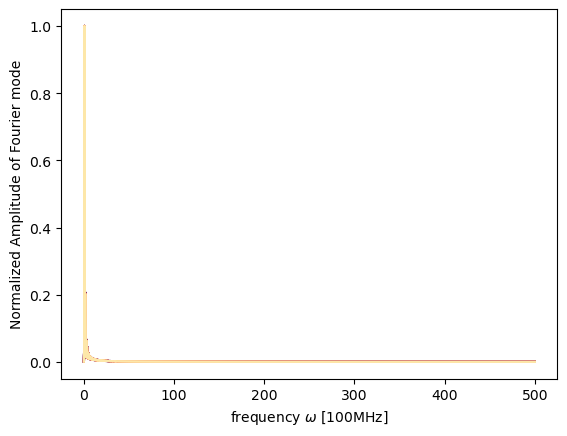

In [482]:
cmap = plt.cm.magma
totn = len(fouriers_smooth)
for i in range(totn):
    color=cmap(i/totn)
    plt.plot(omega_smooth, np.abs(fouriers_smooth[i])/np.max(np.abs(fouriers_smooth[i])), c=color)

plt.ylabel("Normalized Amplitude of Fourier mode")
plt.xlabel(r"frequency $\omega$ [100MHz]")
plt.show()

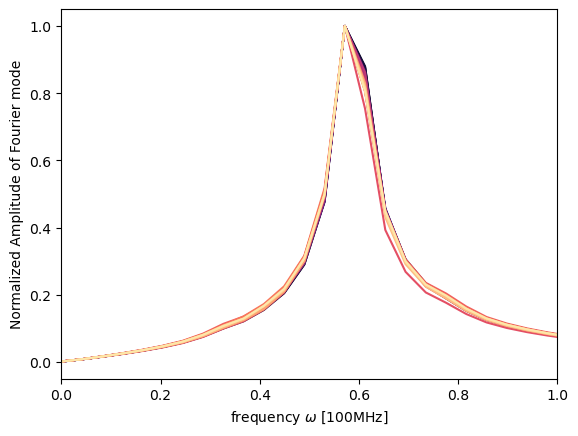

In [483]:
cmap = plt.cm.magma
totn = len(fouriers_smooth)
for i in range(totn):
    color=cmap(i/totn)
    plt.plot(omega_smooth, np.abs(fouriers_smooth[i])/np.max(np.abs(fouriers_smooth[i])), c=color)

plt.ylabel("Normalized Amplitude of Fourier mode")
plt.xlabel(r"frequency $\omega$ [100MHz]")
plt.xlim(0,1)
plt.show()

In [485]:
omega_smooth[:50]

array([0.        , 0.04081633, 0.08163265, 0.12244898, 0.16326531,
       0.20408163, 0.24489796, 0.28571429, 0.32653061, 0.36734694,
       0.40816327, 0.44897959, 0.48979592, 0.53061224, 0.57142857,
       0.6122449 , 0.65306122, 0.69387755, 0.73469388, 0.7755102 ,
       0.81632653, 0.85714286, 0.89795918, 0.93877551, 0.97959184,
       1.02040816, 1.06122449, 1.10204082, 1.14285714, 1.18367347,
       1.2244898 , 1.26530612, 1.30612245, 1.34693878, 1.3877551 ,
       1.42857143, 1.46938776, 1.51020408, 1.55102041, 1.59183673,
       1.63265306, 1.67346939, 1.71428571, 1.75510204, 1.79591837,
       1.83673469, 1.87755102, 1.91836735, 1.95918367, 2.        ])

### General Lorentzian

[1.43935354e-01 4.32621329e+01 3.90418370e-01 6.57064466e+00
 1.02809343e-02]


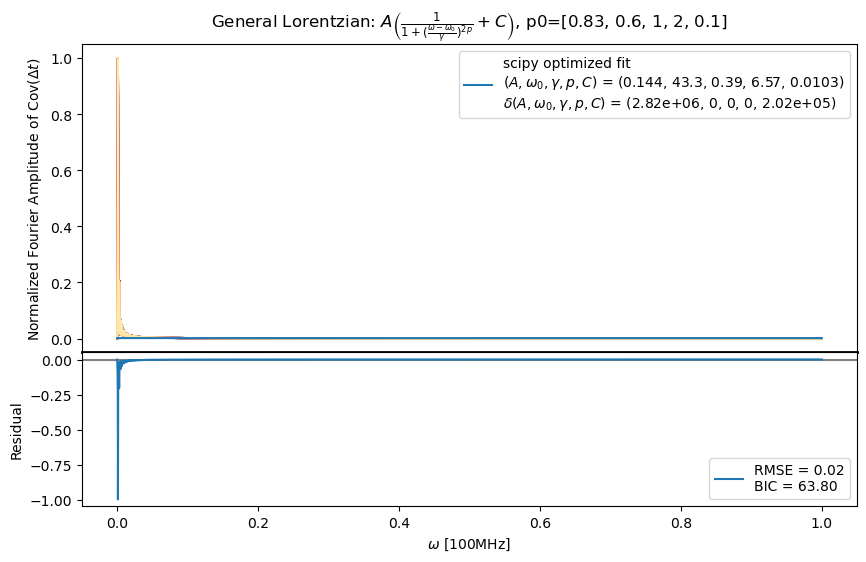

In [467]:
lower=[0,0,0,1, 0]
upper=[np.inf, np.inf, np.inf, 10, 1]
try_fit_freq(General_Lorentzian, r"$A, \omega_0, \gamma, p, C$", r"General Lorentzian: $A \left( \frac{1}{1+(\frac{\omega- \omega_0}{\gamma})^{2p}}+C \right)$", 
             fouriers_smooth, omega_smooth, p0=[0.83,0.6,1,2, 0.1], bounds=(lower, upper))

[0.90189909 0.58599459 0.04923777 1.         0.09166774]


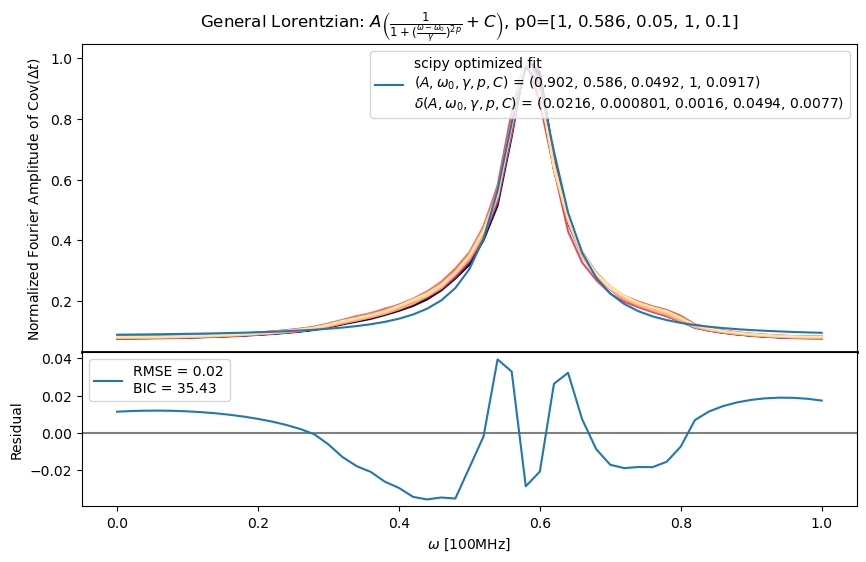

In [421]:
lower=[0,0,0,1, 0]
upper=[np.inf, np.inf, np.inf, 10, 1]
try_fit_freq(General_Lorentzian, r"$A, \omega_0, \gamma, p, C$", r"General Lorentzian: $A \left( \frac{1}{1+(\frac{\omega- \omega_0}{\gamma})^{2p}}+C \right)$", 
             fouriers_smooth, p0=[1,0.586,0.05, 1, 0.1], bounds=(lower, upper))

[0.90189909 0.58599459 0.04923777 1.         0.09166774]


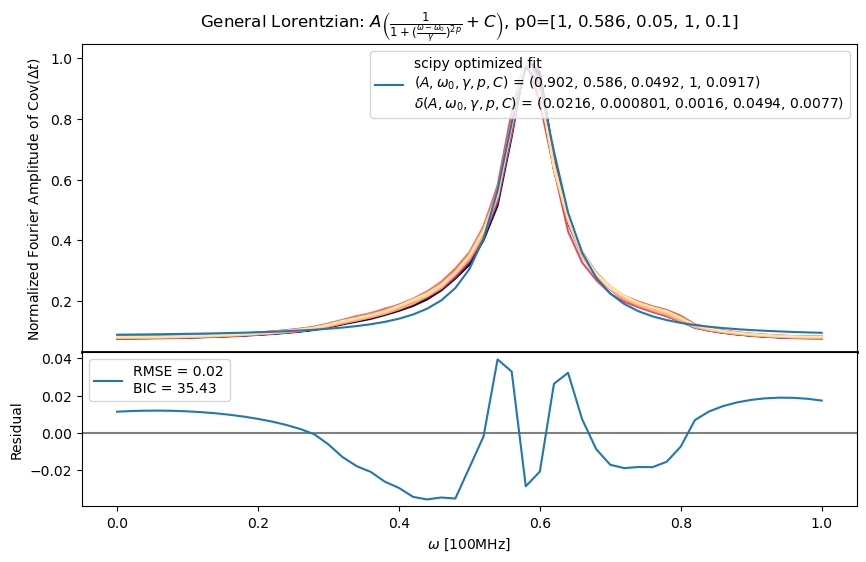

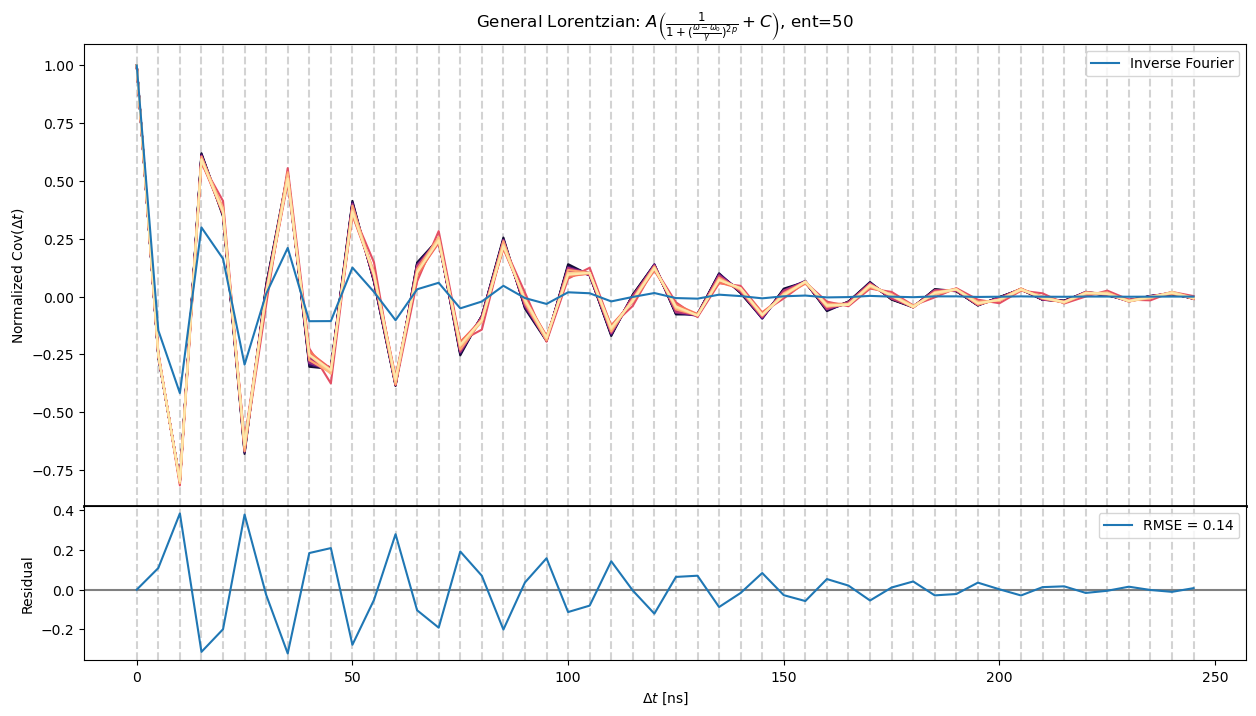

In [423]:
lower=[0,0,0,1, 0]
upper=[np.inf, np.inf, np.inf, 10, 1]
res = fit_freq_adv(General_Lorentzian, r"$A, \omega_0, \gamma, p, C$", r"General Lorentzian: $A \left( \frac{1}{1+(\frac{\omega- \omega_0}{\gamma})^{2p}}+C \right)$", 
             fouriers_smooth, covs, 50, p0=[1,0.586,0.05, 1, 0.1], bounds=(lower, upper))